In [5]:
import numpy as np
import pandas as pd
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


In [6]:

filename = "data/preprocessed_data2_pxrf.xlsx"  # removed an outlier row which had value 2861 for k

df = pd.read_excel(filename)
df.columns = df.columns.astype(str)
print(df.head())
for i, col in enumerate(df.columns):
    print(i, col)
spectral_data = df.iloc[:, 1:434]
output_variable = df.iloc[:, 435:436]

   NaN  349.866666666667    354.95     359.3    365.15     369.5   375.325  \
0    1          0.154092  0.145253  0.132048  0.120393  0.117365  0.116590   
1    2          0.220826  0.194554  0.188793  0.163819  0.154851  0.156193   
2    3          0.223714  0.208908  0.189445  0.175717  0.172087  0.169890   
3    4          0.229010  0.193448  0.174742  0.176795  0.164635  0.163062   
4    5          0.274307  0.245903  0.231115  0.219347  0.206839  0.206962   

      379.7   384.075     389.9  ...    2500.3    2504.5  2507.26666666667  \
0  0.117083  0.118773  0.119548  ...  0.906052  0.904784          0.906521   
1  0.157240  0.156618  0.158353  ...  0.893384  0.894562          0.894388   
2  0.174863  0.175320  0.178920  ...  0.906650  0.907749          0.907098   
3  0.168613  0.165629  0.169800  ...  0.904190  0.902394          0.902522   
4  0.207579  0.208688  0.213001  ...  0.893572  0.893982          0.896283   

      EC  NO3-N   OM   P    K     P.1     K.1  
0  1.404   16.

In [7]:
spectral_data.head()
#output_variable.head()

,349.866666666667,354.95,359.3,365.15,369.5,375.325,379.7,384.075,389.9,394.275,...,2464.26666666667,2467.13333333333,2474.96666666667,2479.2,2482.06666666667,2489.8,2494,2500.3,2504.5,2507.26666666667
0,0.154092,0.145253,0.132048,0.120393,0.117365,0.116590,0.117083,0.118773,0.119548,0.122259,...,0.929058,0.928917,0.921405,0.921029,0.917508,0.912484,0.907742,0.906052,0.904784,0.906521
1,0.220826,0.194554,0.188793,0.163819,0.154851,0.156193,0.157240,0.156618,0.158353,0.162935,...,0.912368,0.911015,0.907437,0.904425,0.904163,0.897574,0.893995,0.893384,0.894562,0.894388
2,0.223714,0.208908,0.189445,0.175717,0.172087,0.169890,0.174863,0.175320,0.178920,0.184015,...,0.925727,0.924954,0.917714,0.917145,0.914013,0.911450,0.908969,0.906650,0.907749,0.907098
3,0.229010,0.193448,0.174742,0.176795,0.164635,0.163062,0.168613,0.165629,0.169800,0.175608,...,0.922672,0.919763,0.913731,0.913431,0.909752,0.906886,0.903463,0.904190,0.902394,0.902522
4,0.274307,0.245903,0.231115,0.219347,0.206839,0.206962,0.207579,0.208688,0.213001,0.217006,...,0.916081,0.912467,0.907127,0.903430,0.902198,0.899569,0.897351,0.893572,0.893982,0.896283


In [8]:
print(spectral_data.shape)
print(output_variable.shape)

(110, 433)
(110, 1)


In [9]:
output_variable.describe()

,NO3-N
count,110.000000
mean,16.070909
std,13.814375
min,3.200000
25%,7.200000
50%,11.200000
75%,21.075000
max,72.200000


Text(0.5, 1.0, 'Output K Distribution')

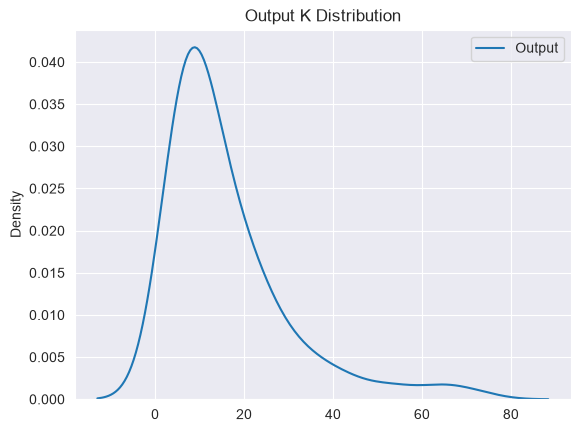

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.kdeplot(output_variable, label='Output')
plt.legend()
plt.title("Output K Distribution")

In [12]:
# skip, no need to apply filter
# from scipy.signal import savgol_filter
# #
# X = savgol_filter(spectral_data.values, window_length=11, polyorder=2, deriv=1, axis=1)
y = output_variable.values.ravel()

In [13]:
# skip
# y_log = np.log1p(output_variable.values.ravel())
# sns.kdeplot(y_log)

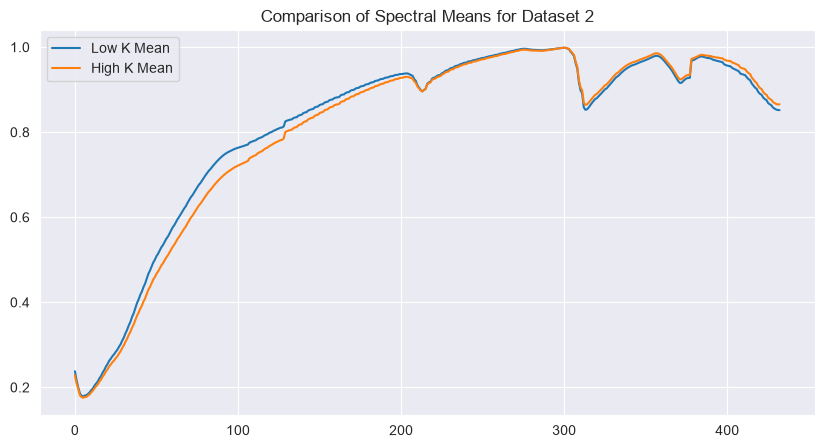

In [14]:

X_train_arr = np.array(spectral_data)

median_val = np.median(y)
low_n = X_train_arr[y <= median_val]
high_n = X_train_arr[y > median_val]

plt.figure(figsize=(10, 5))
plt.plot(np.mean(low_n, axis=0), label='Low K Mean')
plt.plot(np.mean(high_n, axis=0), label='High K Mean')
plt.legend()
plt.title("Comparison of Spectral Means for Dataset 2")
plt.show()

In [24]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor

pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('pca', PCA(n_components=10)),
    ('regressor', Ridge(alpha=1.0))
])

# pipeline = Pipeline([
#     ('scaler', StandardScaler()),
#     ('feat_select', SelectKBest(score_func=f_regression, k=50)),
#     ('rf', RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42))
# ])

# pipeline = Pipeline([
#     ('scaler', MinMaxScaler()),
#     ('pls', PLSRegression(n_components=10))
# ])



from sklearn.base import BaseEstimator, TransformerMixin

# Standard Normal Variate
class SNV(BaseEstimator, TransformerMixin):
    def fit(self, X, y):
        return self
    def transform(self, X):
        X_arr = np.array(X)
        return (X_arr - np.mean(X_arr, axis=1, keepdims=True)) / np.std(X_arr, axis=1, keepdims=True)

#
# pipeline = Pipeline([
#     ('snv', SNV()),
#     ('pls', PLSRegression(n_components=10))
# ])

In [25]:
from sklearn.model_selection import LeaveOneOut, cross_val_predict

cv = LeaveOneOut()
y_pred = cross_val_predict(pipeline, spectral_data, y, cv=cv)

In [26]:
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"LOOCV R2 Score: {r2:.4f}")
print(f"LOOCV RMSE: {rmse:.4f}")

LOOCV R2 Score: 0.0841
LOOCV RMSE: 13.1608


Train/Test split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(spectral_data, y, test_size=0.2, random_state=42)

In [28]:
X_train

,349.866666666667,354.95,359.3,365.15,369.5,375.325,379.7,384.075,389.9,394.275,...,2464.26666666667,2467.13333333333,2474.96666666667,2479.2,2482.06666666667,2489.8,2494,2500.3,2504.5,2507.26666666667
65,0.239411,0.216169,0.194070,0.188055,0.178299,0.172879,0.176096,0.175677,0.178964,0.183125,...,0.864909,0.862345,0.855211,0.851761,0.848917,0.842530,0.840525,0.839080,0.840758,0.838240
26,0.206888,0.185719,0.179242,0.163760,0.160253,0.158420,0.159874,0.158389,0.161801,0.164708,...,0.919810,0.918504,0.915176,0.910585,0.908225,0.903971,0.901022,0.902285,0.900769,0.901948
22,0.196715,0.202006,0.191002,0.167273,0.171493,0.164124,0.164546,0.167597,0.167695,0.168733,...,0.854682,0.851393,0.843429,0.843169,0.838798,0.832652,0.829882,0.822697,0.822437,0.822567
31,0.229963,0.205075,0.180498,0.172705,0.160683,0.161949,0.164780,0.163015,0.164313,0.170374,...,0.912659,0.910706,0.907020,0.901736,0.899871,0.896230,0.891701,0.890014,0.889570,0.890058
47,0.267072,0.234417,0.230043,0.212151,0.198117,0.203797,0.204435,0.203493,0.209690,0.210693,...,0.882949,0.882139,0.876428,0.872215,0.871972,0.868287,0.866748,0.862697,0.862738,0.862778
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,0.169979,0.159260,0.159609,0.136548,0.133469,0.139208,0.135288,0.134833,0.139033,0.137423,...,0.823908,0.820689,0.811543,0.808324,0.804871,0.801092,0.798199,0.791760,0.791713,0.789287
14,0.222353,0.197319,0.182194,0.171583,0.162161,0.161795,0.165515,0.165088,0.165484,0.171034,...,0.932591,0.929623,0.924419,0.923443,0.922345,0.916206,0.914539,0.913929,0.911490,0.915108
92,0.484347,0.445987,0.432743,0.422104,0.414364,0.417592,0.425773,0.430689,0.439860,0.450756,...,0.975885,0.977059,0.974271,0.970505,0.970603,0.967961,0.966543,0.969380,0.966787,0.969135
51,0.224164,0.221536,0.191704,0.183394,0.178138,0.173911,0.178848,0.180340,0.184317,0.188330,...,0.869522,0.868528,0.859625,0.861520,0.854796,0.847693,0.841679,0.842200,0.841726,0.840116


In [29]:

pipeline = Pipeline([
    ('snv', SNV()),
    ('pls', PLSRegression(n_components=10))
])

In [34]:


pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('pca', PCA(n_components=10)),
    ('regressor', Ridge(alpha=1.0))
])

# pipeline = Pipeline([
#     ('scaler', MinMaxScaler()),
#     ('regressor', PLSRegression(n_components=2))
# ])

In [35]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'regressor__n_components': [5, 10, 15, 20, 25]
}

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='r2')
grid.fit(X_train, y_train)

print(f"Best R2: {grid.best_score_}")

ValueError: Invalid parameter 'n_components' for estimator Ridge(). Valid parameters are: ['alpha', 'copy_X', 'fit_intercept', 'max_iter', 'positive', 'random_state', 'solver', 'tol'].

In [36]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print(f"R2 Score: {r2_score(y_test, y_pred)}")
print(f"RMSE: {rmse:.4f}")

R2 Score: 0.007625058649890382
RMSE: 13.1608


Feature selection using lasso

In [37]:
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor


selector = SelectFromModel(estimator=Lasso(alpha=0.4)).fit(X_train, y_train)
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)


In [38]:
X_train_selected

array([[0.72690398],
       [0.60413902],
       [0.58592482],
       [0.66781004],
       [0.70422236],
       [0.74546657],
       [0.64119566],
       [0.73564933],
       [0.79186487],
       [0.65942214],
       [0.73707763],
       [0.75807949],
       [0.52277808],
       [0.76296555],
       [0.74985812],
       [0.68711409],
       [0.75561729],
       [0.58606731],
       [0.55289536],
       [0.52350724],
       [0.60766356],
       [0.64093422],
       [0.65371768],
       [0.49727646],
       [0.69644642],
       [0.70054588],
       [0.65165226],
       [0.57511621],
       [0.68067649],
       [0.63832591],
       [0.49260425],
       [0.79017171],
       [0.69361432],
       [0.81293138],
       [0.71580422],
       [0.70843562],
       [0.57706275],
       [0.73199685],
       [0.75322497],
       [0.67910558],
       [0.63078355],
       [0.61164797],
       [0.53881789],
       [0.90076616],
       [0.63664464],
       [0.52811697],
       [0.76817437],
       [0.806

In [39]:

pls = PLSRegression(n_components=5)
pls.fit(X_train_selected, y_train)

# 5. Prediction & Evaluation
y_pred = pls.predict(X_test_selected)
print(f"R2 Score: {r2_score(y_test, y_pred)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")

ValueError: `n_components` upper bound is 1. Got 5 instead. Reduce `n_components`.

Feature Importance from RF

In [40]:

# 2. Using Random Forest importance
rf = RandomForestRegressor().fit(X_train, y_train)
selector_rf = SelectFromModel(rf, threshold='median').fit(X_train, y_train)
X_train_selected_rf = selector_rf.transform(X_train)
X_test_selected_rf = selector_rf.transform(X_test)

pls = PLSRegression(n_components=6)
pls.fit(X_train_selected_rf, y_train)

y_pred = pls.predict(X_test_selected_rf)
print(f"R2 Score: {r2_score(y_test, y_pred)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")

R2 Score: -0.08636360095666706
RMSE: 15.504938152598372


In [41]:
X_train_selected_rf

array([[0.23941068, 0.21616896, 0.19406952, ..., 0.90994708, 0.84052498,
        0.84075809],
       [0.20688784, 0.1857188 , 0.17924171, ..., 0.96139021, 0.90102159,
        0.90076883],
       [0.19671493, 0.2020061 , 0.19100175, ..., 0.91168387, 0.82988162,
        0.82243719],
       ...,
       [0.48434749, 0.4459866 , 0.4327431 , ..., 0.99320094, 0.96654275,
        0.96678732],
       [0.22416365, 0.22153562, 0.19170396, ..., 0.91209129, 0.8416791 ,
        0.84172645],
       [0.1846483 , 0.15040606, 0.14038554, ..., 0.94620792, 0.87647906,
        0.87193817]], shape=(88, 217))

In [42]:
mask = selector_rf.get_support()

selected_columns = X_train.columns[mask]

# 3. View the results
print(f"Number of features selected: {len(selected_columns)}")
print("Selected columns (wavelengths):")
print(selected_columns)

Number of features selected: 217
Selected columns (wavelengths):
Index(['349.866666666667', '354.95', '359.3', '369.5', '375.325', '379.7',
       '384.075', '389.9', '414.65', '429.2',
       ...
       '2365.06666666667', '2369.6', '2372.6', '2375.6', '2378.6',
       '2389.86666666667', '2397.3', '2417.23333333333', '2494', '2504.5'],
      dtype='str', length=217)


RF with GridSearchCV

In [43]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

# Define a pipeline
pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    # ('pca', PCA(n_components=10)),
    ('model', RandomForestRegressor(random_state=42))
])

# Define parameters to tune
param_grid = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5, 10]
}

# Use 5-fold Cross-Validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Grid search
grid = GridSearchCV(pipeline, param_grid, cv=cv, scoring='r2')
grid.fit(X_train, y_train)

print(f"Best parameters: {grid.best_params_}")
print(f"Best CV RMSE: {-grid.best_score_}")

Best parameters: {'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best CV RMSE: 0.0880853128258674


In [44]:
best_rf = grid.best_estimator_

In [45]:
y_test_pred = best_rf.predict(X_test)

print("Test R²:", r2_score(y_test, y_test_pred))
print("Test MSE:", mean_squared_error(y_test, y_test_pred))

Test R²: -0.0016059093088711673
Test MSE: 221.64694444056968
